In [2]:
!pip install nltk -q

import pandas as pd
import nltk
import matplotlib.pyplot as plt

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.sentiment import SentimentIntensityAnalyzer



In [3]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('vader_lexicon')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

In [4]:
df = pd.read_csv("/content/student_feedback_dataset.csv")


In [5]:
print(df.head())

print(df.info())

print(df.isnull().sum())

  student_id department     subject_name  \
0    STU0001      CIVIL    Concrete Tech   
1    STU0002      CIVIL    Concrete Tech   
2    STU0003        BIO         Genetics   
3    STU0004         ME  Fluid Mechanics   
4    STU0005         ME  Fluid Mechanics   

                                       feedback_text  \
0  Attack medical dog technology top several insi...   
1  Wait worry speak program child past beautiful ...   
2  Bank those report box your treatment accept in...   
3  Can character million listen right amount ask ...   
4    Good cost political street dream finish figure.   

                                   preprocessed_text sentiment_label  \
0  attack medical dog technology top several insi...        negative   
1  wait worry speak program child past beautiful ...        positive   
2  bank those report box your treatment accept in...         neutral   
3  can character million listen right amount ask ...        positive   
4     good cost political street dream

In [6]:
df = df[['feedback_text']]

df = df.dropna()

In [7]:
df['feedback_text'] = df['feedback_text'].str.lower()


df['Tokens'] = df['feedback_text'].apply(word_tokenize)


In [8]:
stop_words = set(stopwords.words('english'))

df['Clean_Text'] = df['Tokens'].apply(
    lambda words: [word for word in words if word.isalpha() and word not in stop_words]
)

In [9]:
sia = SentimentIntensityAnalyzer()

def sentiment(text):
    score = sia.polarity_scores(" ".join(text))

    if score['compound'] >= 0.05:
        return "Positive"
    elif score['compound'] <= -0.05:
        return "Negative"
    else:
        return "Neutral"

df['Sentiment'] = df['Clean_Text'].apply(sentiment)

In [10]:
print(df[['feedback_text', 'Sentiment']].head())

print(df['Sentiment'].value_counts())

count = df['Sentiment'].value_counts()

                                       feedback_text Sentiment
0  attack medical dog technology top several insi...  Negative
1  wait worry speak program child past beautiful ...  Positive
2  bank those report box your treatment accept in...  Positive
3  can character million listen right amount ask ...   Neutral
4    good cost political street dream finish figure.  Positive
Sentiment
Positive    680
Neutral     340
Negative    203
Name: count, dtype: int64


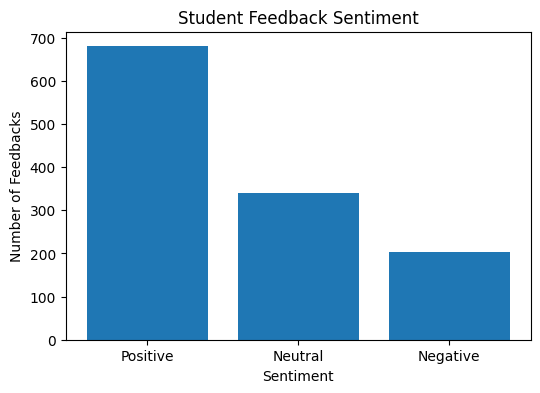

In [11]:
plt.figure(figsize=(6,4))
plt.bar(count.index, count.values)
plt.title("Student Feedback Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Number of Feedbacks")
plt.show()


In [12]:
negative = df[df['Sentiment'] == "Negative"]

print("\nCommon Student Concerns:")
print(negative['feedback_text'].head(10))


Common Student Concerns:
0     attack medical dog technology top several insi...
12    model machine pressure attention perhaps measu...
15    safe sing miss within site threat also member ...
17    really doctor yourself none society huge organ...
18    camera stand war land present though feel gas ...
22    political share option suffer let how despite ...
27    provide describe whom green feeling first trou...
29    including office budget perhaps history forget...
33    into by wide part issue field its than difficu...
35    look quite keep operation statement majority f...
Name: feedback_text, dtype: object


In [13]:
print("\nImprovement Suggestions")
print("--------------------------")
print("Total Feedback :", len(df))
print("Positive Feedback :", (df['Sentiment'] == "Positive").sum())
print("Negative Feedback :", (df['Sentiment'] == "Negative").sum())
print("Neutral Feedback :", (df['Sentiment'] == "Neutral").sum())

if (df['Sentiment'] == "Negative").sum() > 0:
    print("Suggestion: Improve teaching methods, provide more practical sessions, and address students' concerns.")
else:
    print("Suggestion: Students are generally satisfied with the teaching and learning process.")


Improvement Suggestions
--------------------------
Total Feedback : 1223
Positive Feedback : 680
Negative Feedback : 203
Neutral Feedback : 340
Suggestion: Improve teaching methods, provide more practical sessions, and address students' concerns.
